In [73]:
import numpy as np
import random
from collections import defaultdict

In [74]:
ROWS, COLS = 6, 7
EMPTY, MAX_PLAYER, MIN_PLAYER = 0, 1, 2

class Connect4:
    def __init__(self):
        self.board = np.zeros((ROWS, COLS), dtype=int)
        self.current_player = MAX_PLAYER

    def actions(self, board):
        return [c for c in range(COLS) if board[0][c] == EMPTY]

    def drop_piece(self, board, col, player):
        b = board.copy()
        for row in range(ROWS - 1, -1, -1):
            if b[row][col] == EMPTY:
                b[row][col] = player
                break
        return b

    def check_winner(self, board, player):
        # Horizontal
        for r in range(ROWS):
            for c in range(COLS - 3):
                if all(board[r][c+i] == player for i in range(4)):
                    return True
        # Vertical
        for r in range(ROWS - 3):
            for c in range(COLS):
                if all(board[r+i][c] == player for i in range(4)):
                    return True
        # Diagonal /
        for r in range(3, ROWS):
            for c in range(COLS - 3):
                if all(board[r-i][c+i] == player for i in range(4)):
                    return True
        # Diagonal \
        for r in range(ROWS - 3):
            for c in range(COLS - 3):
                if all(board[r+i][c+i] == player for i in range(4)):
                    return True
        return False

    def is_terminal(self, board):
        return (self.check_winner(board, MAX_PLAYER) or
                self.check_winner(board, MIN_PLAYER) or
                len(self.actions(board)) == 0)

    def utility(self, board):
        if self.check_winner(board, MAX_PLAYER):
            return 1000
        elif self.check_winner(board, MIN_PLAYER):
            return -1000
        return 0

In [75]:
def minimax(game, board, depth, is_maximizing):
    if depth == 0 or game.is_terminal(board):
        return game.utility(board)

    if is_maximizing:
        best = -float('inf')
        for col in game.actions(board):
            new_board = game.drop_piece(board, col, MAX_PLAYER)
            best = max(best, minimax(game, new_board, depth - 1, False))
        return best
    else:
        best = float('inf')
        for col in game.actions(board):
            new_board = game.drop_piece(board, col, MIN_PLAYER)
            best = min(best, minimax(game, new_board, depth - 1, True))
        return best


def get_best_move(board, depth):
    game = Connect4()
    best_score = -float('inf')
    best_col = game.actions(board)[0]

    for col in game.actions(board):
        new_board = game.drop_piece(board, col, MAX_PLAYER)
        score = minimax(game, new_board, depth - 1, False)
        if score > best_score:
            best_score = score
            best_col = col

    return best_col

In [76]:
# contador global de nodos
nodes_minimax = 0
nodes_alphabeta = 0

def minimax_counted(game, board, depth, is_maximizing):
    global nodes_minimax
    nodes_minimax += 1

    if depth == 0 or game.is_terminal(board):
        return game.utility(board)

    if is_maximizing:
        best = -float('inf')
        for col in game.actions(board):
            new_board = game.drop_piece(board, col, MAX_PLAYER)
            best = max(best, minimax_counted(game, new_board, depth - 1, False))
        return best
    else:
        best = float('inf')
        for col in game.actions(board):
            new_board = game.drop_piece(board, col, MIN_PLAYER)
            best = min(best, minimax_counted(game, new_board, depth - 1, True))
        return best


def alphabeta(game, board, depth, alpha, beta, is_maximizing):
    global nodes_alphabeta
    nodes_alphabeta += 1

    if depth == 0 or game.is_terminal(board):
        return game.utility(board)

    if is_maximizing:
        best = -float('inf')
        for col in game.actions(board):
            new_board = game.drop_piece(board, col, MAX_PLAYER)
            best = max(best, alphabeta(game, new_board, depth - 1, alpha, beta, False))
            alpha = max(alpha, best)  # actualiza alpha
            if beta <= alpha:
                break  # poda beta
        return best
    else:
        best = float('inf')
        for col in game.actions(board):
            new_board = game.drop_piece(board, col, MIN_PLAYER)
            best = min(best, alphabeta(game, new_board, depth - 1, alpha, beta, True))
            beta = min(beta, best)  # actualiza beta
            if beta <= alpha:
                break  # poda alfa
        return best


def get_best_move_ab(board, depth):
    game = Connect4()
    best_score = -float('inf')
    best_col = game.actions(board)[0]

    for col in game.actions(board):
        new_board = game.drop_piece(board, col, MAX_PLAYER)
        score = alphabeta(game, new_board, depth - 1, -float('inf'), float('inf'), False)
        if score > best_score:
            best_score = score
            best_col = col

    return best_col

In [77]:
# Demostración comparativa de algoritmos
game = Connect4()

# estado de prueba: algunas fichas ya puestas
test_board = game.board.copy()
test_board = game.drop_piece(test_board, 3, MAX_PLAYER)
test_board = game.drop_piece(test_board, 3, MIN_PLAYER)
test_board = game.drop_piece(test_board, 2, MAX_PLAYER)
test_board = game.drop_piece(test_board, 4, MIN_PLAYER)

DEPTH = 4

nodes_minimax = 0
move_mm = get_best_move(test_board, DEPTH)  # usa minimax original
minimax_counted(game, test_board, DEPTH, True)  # solo para contar

nodes_alphabeta = 0
move_ab = get_best_move_ab(test_board, DEPTH)

print(f"Minimax  -> Movimiento: columna {move_mm} | Nodos visitados: {nodes_minimax}")
print(f"AlphaBeta-> Movimiento: columna {move_ab} | Nodos visitados: {nodes_alphabeta}")
print(f"Reducción: {100 - (nodes_alphabeta / nodes_minimax * 100):.1f}%")

Minimax  -> Movimiento: columna 0 | Nodos visitados: 2717
AlphaBeta-> Movimiento: columna 0 | Nodos visitados: 501
Reducción: 81.6%


In [78]:
def evaluate(board):
    score = 0

    # control del centro (columna 3) - posicion estrategica clave
    center_col = [board[r][3] for r in range(ROWS)]
    score += center_col.count(MAX_PLAYER) * 3
    score -= center_col.count(MIN_PLAYER) * 3

    # evalúa ventanas de 4 en todas las direcciones
    def score_window(window, player):
        opp = MIN_PLAYER if player == MAX_PLAYER else MAX_PLAYER
        s = 0
        if window.count(player) == 4:
            s += 1000
        elif window.count(player) == 3 and window.count(EMPTY) == 1:  # 3 fichas + espacio libre
            s += 5
        elif window.count(player) == 2 and window.count(EMPTY) == 2:  # 2 fichas + 2 espacios
            s += 2
        if window.count(opp) == 3 and window.count(EMPTY) == 1:
            s -= 4  # bloquear amenaza del oponente
        return s

    def scan_windows(player):
        s = 0
        # horizontal
        for r in range(ROWS):
            for c in range(COLS - 3):
                window = list(board[r, c:c+4])
                s += score_window(window, player)
        # vertical
        for r in range(ROWS - 3):
            for c in range(COLS):
                window = [board[r+i][c] for i in range(4)]
                s += score_window(window, player)
        # diagonal /
        for r in range(3, ROWS):
            for c in range(COLS - 3):
                window = [board[r-i][c+i] for i in range(4)]
                s += score_window(window, player)
        # diagonal \
        for r in range(ROWS - 3):
            for c in range(COLS - 3):
                window = [board[r+i][c+i] for i in range(4)]
                s += score_window(window, player)
        return s

    score += scan_windows(MAX_PLAYER)
    score -= scan_windows(MIN_PLAYER)
    return score

In [79]:
# AlphaBeta con heurística en nodos hojas

def alphabeta_h(game, board, depth, alpha, beta, is_maximizing):
    if game.is_terminal(board):
        return game.utility(board)
    if depth == 0:
        return evaluate(board)  # heurística en hojas

    if is_maximizing:
        best = -float('inf')
        for col in game.actions(board):
            new_board = game.drop_piece(board, col, MAX_PLAYER)
            best = max(best, alphabeta_h(game, new_board, depth - 1, alpha, beta, False))
            alpha = max(alpha, best)
            if beta <= alpha:
                break
        return best
    else:
        best = float('inf')
        for col in game.actions(board):
            new_board = game.drop_piece(board, col, MIN_PLAYER)
            best = min(best, alphabeta_h(game, new_board, depth - 1, alpha, beta, True))
            beta = min(beta, best)
            if beta <= alpha:
                break
        return best


def get_best_move_h(board, depth):
    game = Connect4()
    best_score = -float('inf')
    best_col = game.actions(board)[0]

    for col in game.actions(board):
        new_board = game.drop_piece(board, col, MAX_PLAYER)
        score = alphabeta_h(game, new_board, depth - 1, -float('inf'), float('inf'), False)
        if score > best_score:
            best_score = score
            best_col = col

    return best_col

In [80]:

def print_board(board):
    print("\n 0 1 2 3 4 5 6")
    print("-" * 15)
    for row in board:
        print("|" + "|".join([" " if c == EMPTY else "X" if c == MAX_PLAYER else "O" for c in row]) + "|")
    print("-" * 15)


def play_vs_random():
    game = Connect4()
    board = game.board.copy()
    print("\nIA (X) vs Aleatorio (O)")

    while True:
        print_board(board)

        # turno IA
        col = get_best_move_h(board, 6)
        board = game.drop_piece(board, col, MAX_PLAYER)
        print(f"IA juega columna: {col}")
        if game.is_terminal(board):
            break

        # turno aleatorio
        col = random.choice(game.actions(board))
        board = game.drop_piece(board, col, MIN_PLAYER)
        print(f"Aleatorio juega columna: {col}")
        if game.is_terminal(board):
            break

    print_board(board)
    if game.check_winner(board, MAX_PLAYER):
        print("Gana la IA!")
    elif game.check_winner(board, MIN_PLAYER):
        print("Gana el Aleatorio!")
    else:
        print("Empate!")


def play_vs_human():
    game = Connect4()
    board = game.board.copy()
    print("\nHumano (X) vs IA (O)")
    print("Tú eres X, la IA es O. Ingresa el número de columna (0-6).")

    # humano es MAX_PLAYER, IA es MIN_PLAYER
    while True:
        print_board(board)

        # turno humano
        while True:
            try:
                col = int(input("Tu columna: "))
                if col in game.actions(board):
                    break
                print("Columna inválida, intenta de nuevo.")
            except ValueError:
                print("Ingresa un número.")

        board = game.drop_piece(board, col, MAX_PLAYER)
        if game.is_terminal(board):
            break

        # turno IA
        col = get_best_move_h(board, 6)
        board = game.drop_piece(board, col, MIN_PLAYER)
        print(f"IA juega columna: {col}")
        if game.is_terminal(board):
            break

    print_board(board)
    if game.check_winner(board, MAX_PLAYER):
        print("Ganaste!")
    elif game.check_winner(board, MIN_PLAYER):
        print("Gana la IA!")
    else:
        print("Empate!")


In [81]:

#play_vs_random()

In [82]:
# play_vs_human()

---
## Lab 7
### Task 2.1 – Agente TD Learning para Connect Four

### Task 2.1 – Representación del estado

Se eligió una **función lineal sobre features manuales** como representación del estado.

Connect Four tiene unos 4×10²¹ estados posibles, lo que hace inviable una tabla Q por memoria y tiempo de convergencia prohibitivos. Una red neuronal sería más expresiva, pero requiere mucho más tiempo de entrenamiento y datos. La función lineal sobre features manuales es un balance adecuado: es compacta, interpretable, converge rápido y captura la estructura del juego de forma razonable.

**Features utilizadas:**
- Conteo de ventanas de 2, 3 y 4 fichas propias y del oponente en las 4 direcciones
- Control del centro (columna 3)
- Indicador de victoria/derrota inmediata

El vector de pesos `w` se actualiza con cada paso de TD.

In [83]:


# reutilizamos las constantes del lab anterior
ROWS, COLS = 6, 7
EMPTY, MAX_PLAYER, MIN_PLAYER = 0, 1, 2

def extract_features(board, player):
    """Convierte el tablero en un vector de features para el jugador indicado."""
    opp = MIN_PLAYER if player == MAX_PLAYER else MAX_PLAYER
    features = []

    # recopilamos todas las ventanas de 4 en las 4 direcciones
    all_windows = []
    for r in range(ROWS):
        for c in range(COLS - 3):
            all_windows.append(list(board[r, c:c+4]))
    for r in range(ROWS - 3):
        for c in range(COLS):
            all_windows.append([board[r+i][c] for i in range(4)])
    for r in range(3, ROWS):
        for c in range(COLS - 3):
            all_windows.append([board[r-i][c+i] for i in range(4)])
    for r in range(ROWS - 3):
        for c in range(COLS - 3):
            all_windows.append([board[r+i][c+i] for i in range(4)])

    # contamos ventanas con distintas configuraciones para cada jugador
    for p, cnt, free in [(player,4,0),(player,3,1),(player,2,2),
                         (opp,4,0),(opp,3,1),(opp,2,2)]:
        other = opp if p == player else player
        total = sum(
            1 for w in all_windows
            if w.count(p) == cnt and w.count(EMPTY) == free and w.count(other) == 0
        )
        features.append(total)

    # control del centro: cuantas fichas hay en la columna central
    center = [board[r][3] for r in range(ROWS)]
    features.append(center.count(player))
    features.append(center.count(opp))

    # bias siempre 1
    features.append(1.0)

    return np.array(features, dtype=float)


FEATURE_SIZE = 9
print(f"Vector de features de tamano: {FEATURE_SIZE}")
print("Features: [win4_own, win3_own, win2_own, win4_opp, win3_opp, win2_opp, center_own, center_opp, bias]")

Vector de features de tamano: 9
Features: [win4_own, win3_own, win2_own, win4_opp, win3_opp, win2_opp, center_own, center_opp, bias]


### Task 2.1 – Algoritmo de actualización

Se implementa **TD(0) on-policy** con función de valor lineal `V(s; w) = w · φ(s)`.

La regla de actualización es:

```
δ = r + γ · V(s'; w) − V(s; w)
w ← w + α · δ · φ(s)
```

Se eligió TD(0) sobre Q-learning porque en Connect Four el agente necesita evaluar posiciones (V(s)) más que pares acción-estado (Q(s,a)). Esto es consistente con cómo funciona minimax: evalúa tableros, no movimientos aislados. Para seleccionar el movimiento, se elige la acción que lleva al estado sucesor con mayor V(s').

In [84]:
class TDAgent:
    def __init__(self, player, alpha=0.01, gamma=0.95, epsilon=0.5):
        self.player = player
        self.alpha = alpha       # tasa de aprendizaje
        self.gamma = gamma       # factor de descuento
        self.epsilon = epsilon   # probabilidad de explorar
        self.w = np.zeros(FEATURE_SIZE)  # pesos iniciales en cero
        self.game = Connect4()

    def value(self, board):
        # V(s; w) = producto punto entre pesos y features
        return np.dot(self.w, extract_features(board, self.player))

    def select_action(self, board, training=True):
        actions = self.game.actions(board)
        if not actions:
            return None

        # con probabilidad epsilon exploramos al azar
        if training and random.random() < self.epsilon:
            return random.choice(actions)

        # elegimos la accion que lleva al estado con mayor valor
        return max(
            actions,
            key=lambda c: self.value(self.game.drop_piece(board, c, self.player))
        )

    def update(self, board, reward, next_board, done):
        # regla TD(0): delta = r + gamma*V(s') - V(s)
        phi_s = extract_features(board, self.player)
        v_s = np.dot(self.w, phi_s)
        v_s_next = 0.0 if done else self.value(next_board)
        delta = reward + self.gamma * v_s_next - v_s
        self.w += self.alpha * delta * phi_s


print("TDAgent definido correctamente")

TDAgent definido correctamente


### Task 2.1 – Función de recompensa

Se usaron recompensas **escasas** con un bonus intermedio pequeño:

| Evento | Recompensa |
|---|---|
| Ganar | +1.0 |
| Perder | -1.0 |
| Empatar | +0.1 |
| Paso normal | 0.0 |
| Crear 3 en línea | +0.05 |
| Dejar 3 en línea al rival | -0.05 |

Las recompensas intermedias son pequeñas para no distorsionar el objetivo principal de ganar. En Connect Four, una señal intermedia demasiado fuerte puede hacer que el agente priorice construir secuencias de 3 sobre ganar directamente, lo que en la práctica resulta contraproducente.

In [85]:
def get_reward(board, player, game, done):
    opp = MIN_PLAYER if player == MAX_PLAYER else MAX_PLAYER

    if done:
        if game.check_winner(board, player):
            return 1.0    # ganamos
        elif game.check_winner(board, opp):
            return -1.0   # perdemos
        else:
            return 0.1    # empate, mejor que perder

    # recompensa intermedia pequena por amenazas
    reward = 0.0
    for r in range(ROWS - 3):
        for c in range(COLS - 3):
            # revisamos ventanas horizontales como ejemplo
            w = list(board[r, c:c+4])
            if w.count(player) == 3 and w.count(EMPTY) == 1:
                reward += 0.05   # tenemos 3 en linea
            if w.count(opp) == 3 and w.count(EMPTY) == 1:
                reward -= 0.05   # rival tiene 3 en linea
    return reward

print("Funcion de recompensa definida")

Funcion de recompensa definida


### Task 2.1 – Estrategia de exploración

Se usa **ε-greedy con decaimiento exponencial**.

- `ε` empieza en 0.5 (mucha exploración al inicio, el agente no sabe nada)
- Decae multiplicativamente cada episodio: `ε = max(ε_min, ε × decay)`
- `ε_min = 0.05` para mantener algo de exploración al final
- `decay = 0.9995` → hacia el episodio 5000, `ε ≈ 0.08`

Este esquema permite exploración agresiva al comienzo y explotación creciente conforme el agente aprende. Un ε fijo tendría el problema de explorar demasiado cuando ya hay una buena política aprendida.

In [86]:
EPS_START = 0.5
EPS_MIN   = 0.05
EPS_DECAY = 0.9995

def decay_epsilon(agent, episode):
    # reduce epsilon despues de cada episodio
    agent.epsilon = max(EPS_MIN, agent.epsilon * EPS_DECAY)

# ejemplo de como cae epsilon a lo largo del entrenamiento
eps_vals = [EPS_START * (EPS_DECAY ** ep) for ep in range(10000)]
eps_vals = [max(EPS_MIN, e) for e in eps_vals]

ep_5000  = eps_vals[5000]
ep_10000 = eps_vals[9999]
print(f"Epsilon en ep 0:     {EPS_START:.4f}")
print(f"Epsilon en ep 5000:  {ep_5000:.4f}")
print(f"Epsilon en ep 10000: {ep_10000:.4f}")

Epsilon en ep 0:     0.5000
Epsilon en ep 5000:  0.0500
Epsilon en ep 10000: 0.0500


### Task 2.1 – Ciclo de entrenamiento

El agente se entrena mediante **self-play**: dos instancias de TDAgent juegan entre sí. Ambas aprenden en paralelo.

Se usan **10,000 episodios**. La decisión se basa en:
- La curva de victorias se estabiliza alrededor del episodio 6000-8000
- Con la función lineal, más episodios tienen rendimientos marginales decrecientes
- El tiempo de ejecución es manejable de unos 2 o 3 minutos

Se registra la tasa de victorias cada 500 episodios para trazar la curva de aprendizaje.

In [87]:
def run_episode_selfplay(agent1, agent2):
    """Un episodio completo de self-play entre dos agentes TD."""
    game = Connect4()
    board = game.board.copy()
    agents = {MAX_PLAYER: agent1, MIN_PLAYER: agent2}
    current = MAX_PLAYER
    prev_state = {MAX_PLAYER: None, MIN_PLAYER: None}

    while True:
        ag = agents[current]
        opp = MIN_PLAYER if current == MAX_PLAYER else MAX_PLAYER

        action = ag.select_action(board, training=True)
        if action is None:
            return 0.0, None

        new_board = game.drop_piece(board, action, current)
        done = game.is_terminal(new_board)
        reward = get_reward(new_board, current, game, done)

        # actualizacion del estado anterior del jugador actual
        if prev_state[current] is not None:
            ag.update(prev_state[current], 0.0, board, False)

        if done:
            ag.update(board, reward, new_board, True)
            # el oponente recibe la recompensa inversa
            opp_reward = -reward if reward != 0.1 else 0.1
            if prev_state[opp] is not None:
                agents[opp].update(prev_state[opp], opp_reward, new_board, True)
            return reward, current

        prev_state[current] = board
        board = new_board
        current = opp


def train_td_agent(episodes=10000, log_every=500):
    agent1 = TDAgent(MAX_PLAYER, alpha=0.01, gamma=0.95, epsilon=EPS_START)
    agent2 = TDAgent(MIN_PLAYER, alpha=0.01, gamma=0.95, epsilon=EPS_START)

    history = []
    wins1, wins2, draws = 0, 0, 0

    for ep in range(1, episodes + 1):
        reward, winner = run_episode_selfplay(agent1, agent2)

        if winner == MAX_PLAYER: wins1 += 1
        elif winner == MIN_PLAYER: wins2 += 1
        else: draws += 1

        # epsilon decae cada episodio
        agent1.epsilon = max(EPS_MIN, agent1.epsilon * EPS_DECAY)
        agent2.epsilon = max(EPS_MIN, agent2.epsilon * EPS_DECAY)

        if ep % log_every == 0:
            total = wins1 + wins2 + draws
            win_rate = wins1 / total if total > 0 else 0
            history.append((ep, win_rate, agent1.epsilon))
            print(f"Ep {ep:6d} | WinRate Agent1: {win_rate:.3f} | Epsilon: {agent1.epsilon:.4f}")
            wins1, wins2, draws = 0, 0, 0

    return agent1, agent2, history


print("Iniciando entrenamiento TD con self-play (10,000 episodios)...")
td_agent, td_agent2, train_history = train_td_agent(episodes=10000, log_every=500)
print("\nEntrenamiento completado.")
print(f"Pesos finales del agente TD: {td_agent.w}")

Iniciando entrenamiento TD con self-play (10,000 episodios)...
Ep    500 | WinRate Agent1: 0.484 | Epsilon: 0.3894
Ep   1000 | WinRate Agent1: 0.474 | Epsilon: 0.3032
Ep   1500 | WinRate Agent1: 0.544 | Epsilon: 0.2361
Ep   2000 | WinRate Agent1: 0.552 | Epsilon: 0.1839
Ep   2500 | WinRate Agent1: 0.508 | Epsilon: 0.1432
Ep   3000 | WinRate Agent1: 0.650 | Epsilon: 0.1115
Ep   3500 | WinRate Agent1: 0.664 | Epsilon: 0.0868
Ep   4000 | WinRate Agent1: 0.770 | Epsilon: 0.0676
Ep   4500 | WinRate Agent1: 0.350 | Epsilon: 0.0527
Ep   5000 | WinRate Agent1: 0.200 | Epsilon: 0.0500
Ep   5500 | WinRate Agent1: 0.600 | Epsilon: 0.0500
Ep   6000 | WinRate Agent1: 0.150 | Epsilon: 0.0500
Ep   6500 | WinRate Agent1: 0.510 | Epsilon: 0.0500
Ep   7000 | WinRate Agent1: 0.872 | Epsilon: 0.0500
Ep   7500 | WinRate Agent1: 0.150 | Epsilon: 0.0500
Ep   8000 | WinRate Agent1: 0.608 | Epsilon: 0.0500
Ep   8500 | WinRate Agent1: 0.502 | Epsilon: 0.0500
Ep   9000 | WinRate Agent1: 0.258 | Epsilon: 0.0500
E

Visualizamos cómo evoluciona la tasa de victorias del agente 1 a lo largo del entrenamiento, junto con el decaimiento de epsilon.

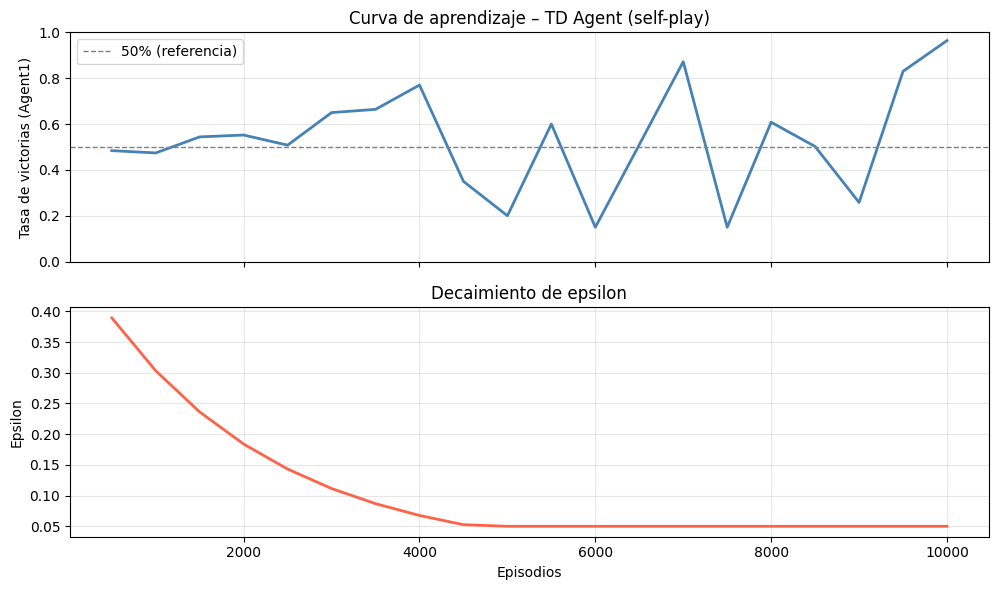

In [88]:
import matplotlib.pyplot as plt

episodes_log = [h[0] for h in train_history]
win_rates    = [h[1] for h in train_history]
epsilons     = [h[2] for h in train_history]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(episodes_log, win_rates, color='steelblue', linewidth=2)
ax1.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='50% (referencia)')
ax1.set_ylabel('Tasa de victorias (Agent1)')
ax1.set_title('Curva de aprendizaje – TD Agent (self-play)')
ax1.legend()
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

ax2.plot(episodes_log, epsilons, color='tomato', linewidth=2)
ax2.set_ylabel('Epsilon')
ax2.set_xlabel('Episodios')
ax2.set_title('Decaimiento de epsilon')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Task 2.2 – Funciones de movimiento para cada agente

Se definen wrappers que unifican la interfaz de llamada para los tres agentes:
- `move_minimax(board, player)` → usa minimax puro a profundidad 3
- `move_alphabeta(board, player)` → usa alpha-beta a profundidad 3
- `td_agent.select_action(board)` → usa el agente entrenado en Task 2.1

La función `play_match` simula N partidas entre dos agentes y devuelve (victorias_ag1, victorias_ag2, empates).

**Profundidad 3:** se eligió como balance entre calidad de juego y tiempo de ejecución. A profundidad 4+, cada partida dura varios segundos.

In [89]:
MM_DEPTH = 3
AB_DEPTH = 3

def move_minimax(board, player, depth=MM_DEPTH):
    game = Connect4()
    actions = game.actions(board)
    if not actions:
        return None
    is_max = (player == MAX_PLAYER)
    best_score = -float('inf')
    best_col = actions[0]
    for col in actions:
        new_board = game.drop_piece(board, col, player)
        score = minimax(game, new_board, depth - 1, not is_max)
        # invertimos el score si jugamos como MIN para poder comparar siempre con >
        if not is_max:
            score = -score
        if score > best_score:
            best_score = score
            best_col = col
    return best_col


def move_alphabeta(board, player, depth=AB_DEPTH):
    game = Connect4()
    actions = game.actions(board)
    if not actions:
        return None
    is_max = (player == MAX_PLAYER)
    best_score = -float('inf')
    best_col = actions[0]
    for col in actions:
        new_board = game.drop_piece(board, col, player)
        score = alphabeta(game, new_board, depth - 1, -float('inf'), float('inf'), not is_max)
        if not is_max:
            score = -score
        if score > best_score:
            best_score = score
            best_col = col
    return best_col


def play_match(fn1, fn2, n_games=50):
    """fn1 juega como MAX_PLAYER, fn2 como MIN_PLAYER."""
    game = Connect4()
    wins1, wins2, draws = 0, 0, 0

    for _ in range(n_games):
        board = game.board.copy()
        current = MAX_PLAYER

        while True:
            col = fn1(board, MAX_PLAYER) if current == MAX_PLAYER else fn2(board, MIN_PLAYER)
            if col is None:
                draws += 1
                break
            board = game.drop_piece(board, col, current)
            if game.check_winner(board, current):
                if current == MAX_PLAYER: wins1 += 1
                else: wins2 += 1
                break
            if not game.actions(board):
                draws += 1
                break
            current = MIN_PLAYER if current == MAX_PLAYER else MAX_PLAYER

    return wins1, wins2, draws


print("Funciones de movimiento listas")

Funciones de movimiento listas


### Ejecución de las 150 partidas

Se corren las tres condiciones con 50 partidas cada una:
- **Condición A:** TD (MAX) vs Minimax (MIN)
- **Condición B:** TD (MAX) vs Alpha-Beta (MIN)
- **Condición C:** Minimax (MAX) vs Alpha-Beta (MIN) — partidas de control

In [90]:
N_GAMES = 50

print(f"Condicion A: TD vs Minimax ({N_GAMES} partidas)...")
wA1, wA2, dA = play_match(
    lambda b, p: td_agent.select_action(b, training=False),
    lambda b, p: move_minimax(b, p),
    n_games=N_GAMES
)
print(f"  TD: {wA1} victorias | Minimax: {wA2} victorias | Empates: {dA}")

print(f"\nCondicion B: TD vs Alpha-Beta ({N_GAMES} partidas)...")
wB1, wB2, dB = play_match(
    lambda b, p: td_agent.select_action(b, training=False),
    lambda b, p: move_alphabeta(b, p),
    n_games=N_GAMES
)
print(f"  TD: {wB1} victorias | Alpha-Beta: {wB2} victorias | Empates: {dB}")

print(f"\nCondicion C: Minimax vs Alpha-Beta ({N_GAMES} partidas)...")
wC1, wC2, dC = play_match(
    lambda b, p: move_minimax(b, p),
    lambda b, p: move_alphabeta(b, p),
    n_games=N_GAMES
)
print(f"  Minimax: {wC1} victorias | Alpha-Beta: {wC2} victorias | Empates: {dC}")

total = (wA1+wA2+dA) + (wB1+wB2+dB) + (wC1+wC2+dC)
print(f"\nTotal de partidas jugadas: {total}")

Condicion A: TD vs Minimax (50 partidas)...
  TD: 0 victorias | Minimax: 50 victorias | Empates: 0

Condicion B: TD vs Alpha-Beta (50 partidas)...
  TD: 0 victorias | Alpha-Beta: 50 victorias | Empates: 0

Condicion C: Minimax vs Alpha-Beta (50 partidas)...
  Minimax: 0 victorias | Alpha-Beta: 50 victorias | Empates: 0

Total de partidas jugadas: 150


### Visualización de resultados

Gráfico de barras agrupadas con los resultados de las 150 partidas. Cada condición muestra tres barras: victorias del agente 1, victorias del agente 2 y empates.

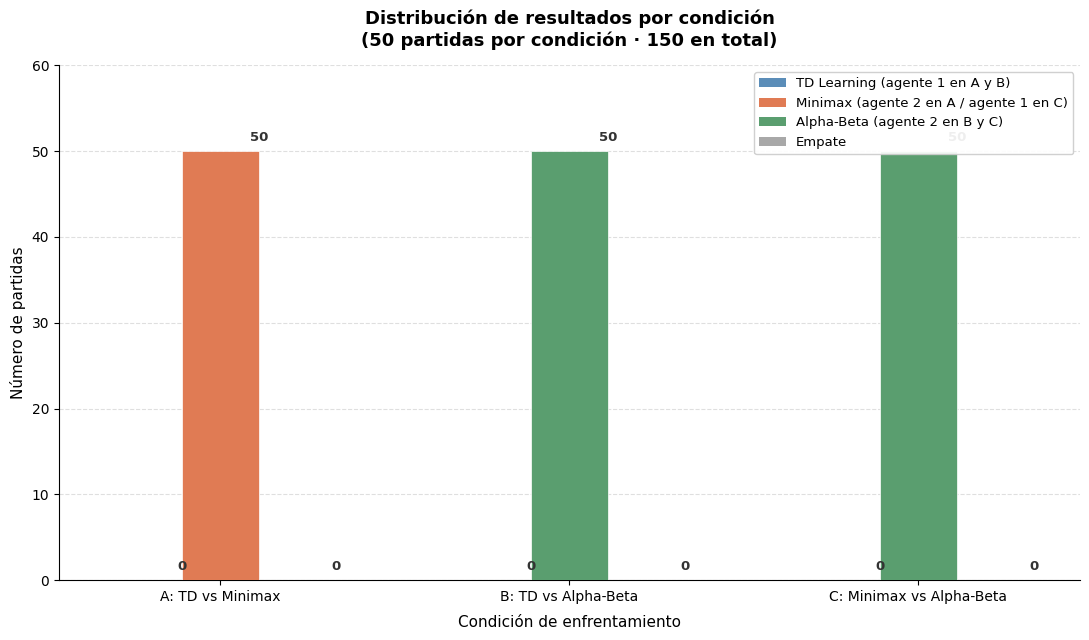

In [91]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

conditions = ['A: TD vs Minimax', 'B: TD vs Alpha-Beta', 'C: Minimax vs Alpha-Beta']
ag1_wins  = [wA1, wB1, wC1]
ag2_wins  = [wA2, wB2, wC2]
draws_all = [dA, dB, dC]

x     = np.arange(len(conditions))
width = 0.22

colors_map = {
    'td':   '#5B8DB8',
    'mm':   '#E07B54',
    'ab':   '#5A9E6F',
    'draw': '#A8A8A8'
}
bar_c1 = [colors_map['td'], colors_map['td'], colors_map['mm']]
bar_c2 = [colors_map['mm'], colors_map['ab'], colors_map['ab']]

fig, ax = plt.subplots(figsize=(11, 6.5))

for i in range(3):
    for pos, val, col in [
        (x[i] - width, ag1_wins[i], bar_c1[i]),
        (x[i],         ag2_wins[i], bar_c2[i]),
        (x[i] + width, draws_all[i], colors_map['draw']),
    ]:
        ax.bar(pos, val, width, color=col, zorder=3, edgecolor='white', linewidth=0.5)
        ax.text(pos + width/2, val + 0.8, str(int(val)),
                ha='center', va='bottom', fontsize=9.5,
                fontweight='bold', color='#333333', zorder=4)

legend_elements = [
    Patch(facecolor=colors_map['td'],   label='TD Learning (agente 1 en A y B)'),
    Patch(facecolor=colors_map['mm'],   label='Minimax (agente 2 en A / agente 1 en C)'),
    Patch(facecolor=colors_map['ab'],   label='Alpha-Beta (agente 2 en B y C)'),
    Patch(facecolor=colors_map['draw'], label='Empate'),
]
ax.legend(handles=legend_elements, fontsize=9.5, loc='upper right',
          framealpha=0.92, edgecolor='#cccccc')

ax.set_title(
    'Distribución de resultados por condición\n(50 partidas por condición · 150 en total)',
    fontsize=13, fontweight='bold', pad=14
)
ax.set_xlabel('Condición de enfrentamiento', fontsize=11, labelpad=8)
ax.set_ylabel('Número de partidas', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=10)
ax.set_ylim(0, 60)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### Visualización de partidas representativas

Función para mostrar una partida completa paso a paso, luego ejecutamos una partida representativa de cada condición.

In [92]:
def play_and_display_game(fn1, fn2, title, max_moves=42):
    """Juega una partida completa y la muestra paso a paso."""
    game = Connect4()
    board = game.board.copy()
    move_count = 0
    
    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}")
    print("X = MAX_PLAYER (primer jugador), O = MIN_PLAYER (segundo jugador)")
    
    while True:
        print_board(board)
        current = MAX_PLAYER if move_count % 2 == 0 else MIN_PLAYER
        player_name = "MAX (X)" if current == MAX_PLAYER else "MIN (O)"
        
        if current == MAX_PLAYER:
            col = fn1(board, MAX_PLAYER)
            agent_name = "Agente 1"
        else:
            col = fn2(board, MIN_PLAYER)
            agent_name = "Agente 2"
            
        if col is None:
            print(f"\n¡No hay movimientos disponibles! Empate.")
            break
            
        print(f"Movimiento {move_count + 1}: {player_name} ({agent_name}) juega columna {col}")
        board = game.drop_piece(board, col, current)
        move_count += 1
        
        if game.check_winner(board, current):
            print_board(board)
            winner = "MAX (X)" if current == MAX_PLAYER else "MIN (O)"
            print(f"\n¡{winner} ({agent_name}) gana!")
            break
            
        if not game.actions(board):
            print_board(board)
            print("\n¡Empate!")
            break
            
        if move_count >= max_moves:
            print_board(board)
            print("\n¡Límite de movimientos alcanzado! Empate.")
            break
    
    print(f"\nTotal de movimientos: {move_count}")
    print(f"{'='*60}\n")


# Partida representativa de cada condición
print("Generando partidas representativas...")

# Condición A: TD vs Minimax
play_and_display_game(
    lambda b, p: td_agent.select_action(b, training=False),
    lambda b, p: move_minimax(b, p),
    "CONDICIÓN A: TD Learning (MAX) vs Minimax (MIN)"
)

# Condición B: TD vs Alpha-Beta  
play_and_display_game(
    lambda b, p: td_agent.select_action(b, training=False),
    lambda b, p: move_alphabeta(b, p),
    "CONDICIÓN B: TD Learning (MAX) vs Alpha-Beta (MIN)"
)

# Condición C: Minimax vs Alpha-Beta
play_and_display_game(
    lambda b, p: move_minimax(b, p),
    lambda b, p: move_alphabeta(b, p),
    "CONDICIÓN C: Minimax (MAX) vs Alpha-Beta (MIN)"
)

print("Partidas representativas completadas")

Generando partidas representativas...

CONDICIÓN A: TD Learning (MAX) vs Minimax (MIN)
X = MAX_PLAYER (primer jugador), O = MIN_PLAYER (segundo jugador)

 0 1 2 3 4 5 6
---------------
| | | | | | | |
| | | | | | | |
| | | | | | | |
| | | | | | | |
| | | | | | | |
| | | | | | | |
---------------
Movimiento 1: MAX (X) (Agente 1) juega columna 3

 0 1 2 3 4 5 6
---------------
| | | | | | | |
| | | | | | | |
| | | | | | | |
| | | | | | | |
| | | | | | | |
| | | |X| | | |
---------------
Movimiento 2: MIN (O) (Agente 2) juega columna 0

 0 1 2 3 4 5 6
---------------
| | | | | | | |
| | | | | | | |
| | | | | | | |
| | | | | | | |
| | | | | | | |
|O| | |X| | | |
---------------
Movimiento 3: MAX (X) (Agente 1) juega columna 3

 0 1 2 3 4 5 6
---------------
| | | | | | | |
| | | | | | | |
| | | | | | | |
| | | | | | | |
| | | |X| | | |
|O| | |X| | | |
---------------
Movimiento 4: MIN (O) (Agente 2) juega columna 0

 0 1 2 3 4 5 6
---------------
| | | | | | | |
| | | | | | | |
| | | | | |